the image to be analyzed is medium_risk_12.jpg


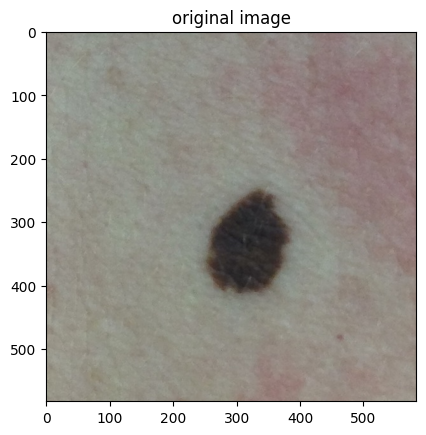

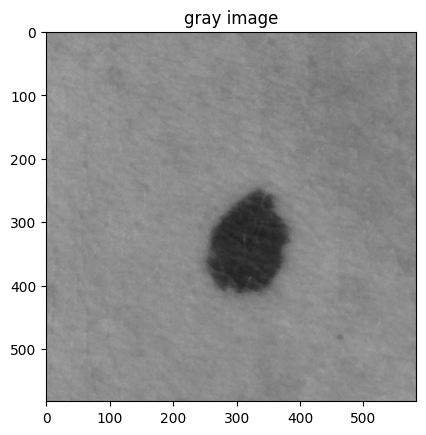

Number of points in each cluster found by DBSCAN:  [14997]
Indexes of the found clusters:  [0]


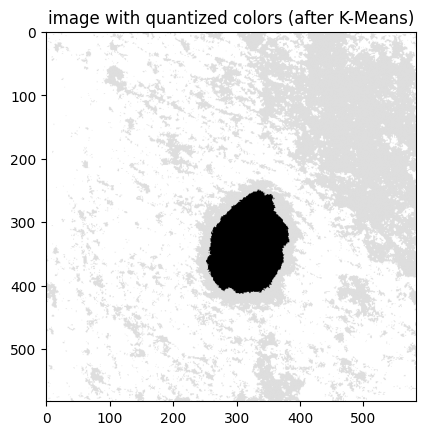

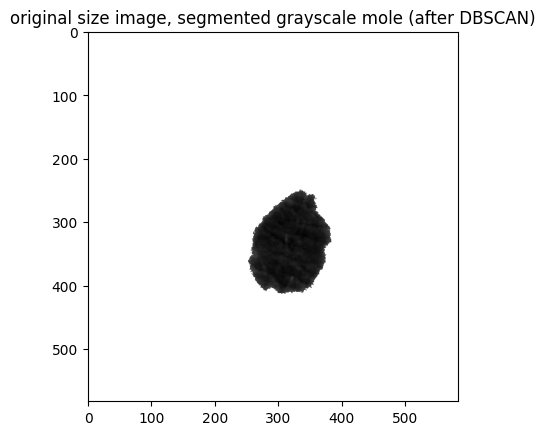

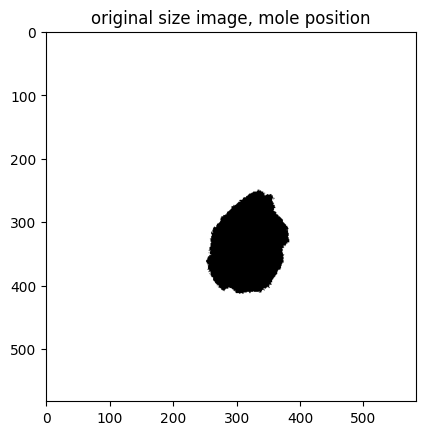

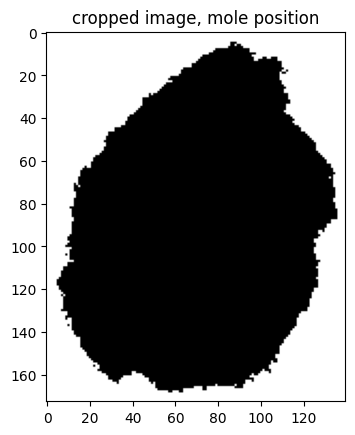

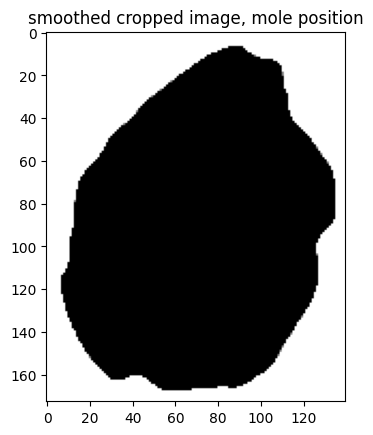

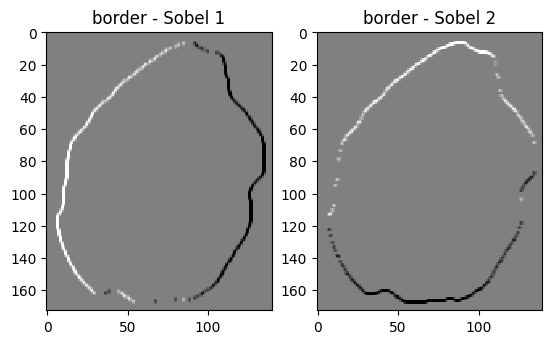

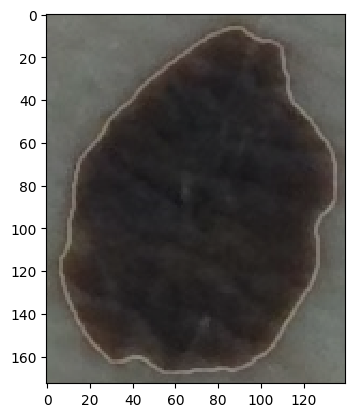

In [4]:
import numpy as np
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
import os
import sys

class Moles():
    def __init__(self, plotfig, image_title):
        ## Set the folder path where the images are stored
        self.folderpath = './moles/' 
        self.files = os.listdir(self.folderpath)
        self.plotfig = plotfig # plotting flag
        self.image_title = image_title

    def greyscale(self):
        ## Read the image to be analyzed and convert it to grayscale
        np.set_printoptions(precision = 2) # use only two decimal digits when printing numbers
        plt.close('all') # close previously opened pictures
        ifile = self.files.index(self.image_title) # title of the file to be analyzed
        filein = self.files[ifile] # file to be analyzed (low_risk, medium_risk or melanoma)
        print(f"the image to be analyzed is {filein}")
        self.im_or = mpimg.imread(self.folderpath + filein) 
        self.gray_image = np.mean(self.im_or, axis = 2).astype(np.uint8) # convert to grayscale
        self.N1,self.N2,self.N3 = self.im_or.shape # note: N3 is 3, the number of elementary colors, i.e. red, green, blue
        self.N1,self.N2 = self.gray_image.shape
        # im_or is Ndarray N1 x N2 x 3 unint8 (integers from 0 to 255)
        # gray_image is an Ndaaray N1 x N2 unint8 (integers from 0 to 255)
        # plot the images, to check them:
        plt.figure()
        plt.imshow(self.im_or,interpolation=None)
        plt.title('original image')
        plt.figure()
        plt.imshow(self.gray_image, cmap='gray', vmin=0, vmax=255, interpolation=None)
        plt.title('gray image')
        plt.show()

    def K_means(self):
        ## Get a simplified image with only Ncluster colors
        
        # instantiate the object K-means:
        Ncluster = 3 # number of clusters/quantized colors we want to have in the simpified image
        self.kmeans = KMeans(n_clusters = Ncluster, random_state = 0) # instantiate the object K-means
        im_1D = self.gray_image.reshape((self.N1*self.N2,1)) 
        self.kmeans.fit(im_1D) # run K-means on the colors of the gray image (i.e. on the uint8 values):

        # get the centroids (i.e. the 3 grey colors). Note that the centroids take real values,
        # we must convert these values to uint8 to properly see the quantized image
        Ncluster = len(self.kmeans.cluster_centers_) # Warning: it is possible that the found clusters is less than required
        self.kmeans_centroids = self.kmeans.cluster_centers_.astype('uint8')

        # copy im_1D into im_1D_quant and get the quantized image
        im_1D_quant = im_1D.copy()
        for kc in range(Ncluster):
            im_1D_quant[(self.kmeans.labels_ == kc),:] = self.kmeans_centroids[kc,:] # substitute the centroid value in the pixels that belong to the cluster
        im_quant = im_1D_quant.reshape((self.N1,self.N2))

        if self.plotfig:
            plt.figure()
            plt.imshow(im_quant,cmap='gray',interpolation=None)
            plt.title('image with quantized colors (after K-Means)')

    def DBSCAN(self):
        ## Find the likely position of the mole using DBSCAN

        ## Preliminary steps to find the contour after the clustering
        # 1: find the darkest color found by k-means, since the darkest color corresponds to the mole:
        centroids = self.kmeans_centroids # 3 value represent grayscale color
        darkest_col = centroids.argmin() # darkest color corresponds to minimum grayscale value
        # 2: define the 2D-array im_clust where in position i,j you have the index of the cluster pixel i,j belongs to 
        im_clust = self.kmeans.labels_.reshape(self.N1,self.N2)
        # 3: find the positions i,j where im_clust is equal to i_col (cluster with the darkest color)
            # the 2D Ndarray mole_pos stores the coordinates i,j only of the pixels in cluster i_col
        mole_pos = np.argwhere(im_clust == darkest_col) # Ndarray with two columns, storing the index [i,j] of the dark pixels 

        # Find the likely position of the mole using DBSCAN
        # insert parameters !
        epsilon = 4
        if np.isnan(epsilon):
            print("SET AN APPROPRIATE VALUE FOR epsilon!")
            sys.exit()
        M = 15
        if np.isnan(M):
            print("SET AN APPROPRIATE VALUE FOR M!")
            sys.exit()
        # --
        clusters = DBSCAN(eps = epsilon, min_samples = M, metric = 'euclidean').fit(mole_pos)  # fit DBSCAN on the positions of the dark pixels (closeby dark pixels will belong to the same cluster)
        id_clusters, count_id_clusters = np.unique(clusters.labels_,return_counts=True) # count the number of obtained clusters (i.e. groups of closeby dark pixels)
        print('Number of points in each cluster found by DBSCAN: ', count_id_clusters)
        print('Indexes of the found clusters: ', id_clusters)

        # select the clusters that could potentially correspond to the mole

        # select the cluster that most likely corresponds to the mole
        image_center = np.array([self.N1/2, self.N2/2])
        min_dist_from_center = float('inf') 

        best_cluster_id = np.nan
        unique_labels = np.unique(clusters.labels_)

        for label in unique_labels:
            # ignore the rumor cluster
            if label == -1:
                continue
            # extract the pixels that belong to the current cluster
            # cluster_pixels is an array [[r1, c1], [r2, c2], ...]
            cluster_pixels = mole_pos[clusters.labels_ == label]
            # filter the small clusters
            if len(cluster_pixels) < 1000:
                continue
            cluster_centroid = np.mean(cluster_pixels, axis=0)
            dist = np.linalg.norm(cluster_centroid - image_center)

            if dist < min_dist_from_center:
                min_dist_from_center = dist
                best_cluster_id = label

        i_mole = best_cluster_id

        if np.isnan(i_mole):
            print("SET AN APPROPRIATE VALUE FOR i_mole (index of the cluster that contains the mole)!")
            sys.exit()
        self.true_mole_pos = mole_pos[clusters.labels_ == i_mole] # pixel indexes [i,j] in the cluster that corresponds to the mole
        self.im_only_mole_gray = 0 * self.gray_image - 1 # white image
        x = self.true_mole_pos[:,0]
        y = self.true_mole_pos[:,1]
        self.im_only_mole_gray[x,y] = self.gray_image[x,y]
        if self.plotfig:
            plt.figure()
            plt.imshow(self.im_only_mole_gray, cmap='gray', interpolation=None)
            plt.title('original size image, segmented grayscale mole (after DBSCAN)')
        self.im_mole_pos = np.ones((self.N1,self.N2),dtype='uint8')*255 # white image
        self.im_mole_pos[x,y]=0 # black where the mole is present
        if self.plotfig:
            plt.figure()
            plt.imshow(self.im_mole_pos,cmap='gray',interpolation=None)
            plt.title('original size image, mole position')

    def crop(self):
        ## Find the cropped original image
        margin = 5  # pixels around the mole (used for smoothing the image)
        if np.isnan(margin):
            print("SET AN APPROPRIATE VALUE FOR margin!")
            sys.exit()
        min_x = np.min(self.true_mole_pos[:,0])-margin
        max_x = np.max(self.true_mole_pos[:,0])+margin
        min_y = np.min(self.true_mole_pos[:,1])-margin
        max_y = np.max(self.true_mole_pos[:,1])+margin
        self.im_cropped_gray_red = self.im_only_mole_gray[min_x:max_x,min_y:max_y]
        self.im_cropped_col = self.im_or[min_x:max_x,min_y:max_y,:]
        self.im_cropped_mole_pos = self.im_mole_pos[min_x:max_x,min_y:max_y]

        if self.plotfig:
            plt.figure()
            plt.imshow(self.im_cropped_mole_pos,cmap='gray',interpolation=None)
            plt.title('cropped image, mole position')

    def smooth(self):
        #%% Smooth the image
        delta = 5
        if np.isnan(delta):
            print("SET AN APPROPRIATE VALUE FOR delta!")
            sys.exit()
        self.N1,self.N2 = self.im_cropped_mole_pos.shape
        self.im_cropped_mole_pos_filt = 0*self.im_cropped_mole_pos+255# white image
        for kr in range(delta,self.N1-delta):
            for kc in range(delta,self.N2-delta):
                sub = self.im_cropped_mole_pos[kr-delta:kr+delta,kc-delta:kc+delta]
                self.im_cropped_mole_pos_filt[kr,kc] = np.median(sub)
        if self.plotfig:     
            plt.figure()      
            plt.imshow(self.im_cropped_mole_pos_filt,cmap='gray',interpolation=None)  
            plt.title('smoothed cropped image, mole position')       
    
    def sobel_filters(self):
        ## Apply Sobel filters
        kern1 = np.array([[1,0,-1],[2,0,-2],[1,0,-1]])# Sobel filter
        kern2= kern1.T

        im_work = self.im_cropped_mole_pos_filt.astype(float)
        N1, N2 = im_work.shape

        # 3. Initialize the output image
        self.sobel1_img = np.zeros((N1, N2))
        self.sobel2_img = np.zeros((N1, N2))

        # 4. Doppio ciclo for per la convoluzione manuale
        # Partiamo da 1 e finiamo a N-1 per non uscire dai bordi col kernel 3x3
        for kr in range(1, N1-1):
            for kc in range(1, N2-1):
                # Extract the sub-matrix 3x3 centered in [r, c]
                sub_img = im_work[kr-1:kr+2, kc-1:kc+2]
                
                # Apply Hx
                val_x = np.sum(sub_img * kern1)
                self.sobel1_img[kr, kc] = val_x
                
                # Apply Hy
                val_y = np.sum(sub_img * kern2)
                self.sobel2_img[kr, kc] = val_y
        if self.plotfig:
            plt.figure()
            plt.subplot(1, 2, 1)
            plt.imshow(self.sobel1_img, cmap='gray', interpolation='none')
            plt.title('border - Sobel 1')
            plt.subplot(1, 2, 2)
            plt.imshow(self.sobel2_img, cmap='gray', interpolation='none')
            plt.title('border - Sobel 2')     

    def border(self):
        ## get the border and plot the cropped color image and the border superimposed

        # Combine the two Sobel filter outputs to get the gradient magnitude
        # This implements the logic: Border = sqrt(Gx^2 + Gy^2)
        border = np.sqrt(self.sobel1_img**2 + self.sobel2_img**2)

        # Optional (Pragmatic Engineering Tip): 
        # Normalize the border to the 0-255 range for better visualization compatibility, 
        # although matplotlib usually handles floats fine.
        max_val = np.max(border)
        if max_val > 0:
            border = border / max_val * 255
        
        if np.isnan(border).any():
            print("IMPLEMENT FILTERING WITH SOBEL FILTERS AND FIND THE BORDER")
            sys.exit()
        plt.figure()
        plt.imshow(self.im_cropped_col, interpolation='none')
        plt.imshow(border,cmap='gray', interpolation='none', alpha=0.2)

if __name__ == '__main__':
    mole = Moles(plotfig = True, image_title = 'medium_risk_12.jpg' )
    mole.greyscale()
    mole.K_means()
    mole.DBSCAN()
    mole.crop()
    mole.smooth()
    mole.sobel_filters()
    mole.border()
    plt.show()